# Import Libraries

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# LogisticRegression class Implementation

In [4]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = 0
        self.cost_history = []
    
    def sigmoid(self, z):
        # Sigmoid activationfunction
        return 1 / (1 + np.exp(-z))
    
    def cost(self, y_pred, y_true):
        # Cross-entropy loss
        return - (1 / len(y_true)) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def fit(self, X, y):
        # Initialize weights and bias
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        
        # Gradient descent
        for i in range(self.iterations):
            # Linear combination
            linear_model = np.dot(X, self.weights) + self.bias
            
            # Sigmoid activation
            y_pred = self.sigmoid(linear_model)
            
            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # Compute cost
            self.cost_history.append(self.cost(y_pred, y))
    
    def predict(self, X):
        return (self.sigmoid(np.dot(X, self.weights) + self.bias) >= 0.5).astype(int)

# Prepare Data

In [5]:
# Generate synthetic data
np.random.seed(42)
X = np.random.randn(100, 2) * 10
y = (np.dot(X, np.array([3, -2])) + 1 > 0).astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the Model

In [6]:
# Initialize and Fit Model
model = LogisticRegressionScratch(learning_rate=0.01, iterations=1000)
model.fit(X_train, y_train)

# Evaluate the Model

In [7]:
# Evaluate the Model
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


# Visualize Cost Function Convergence

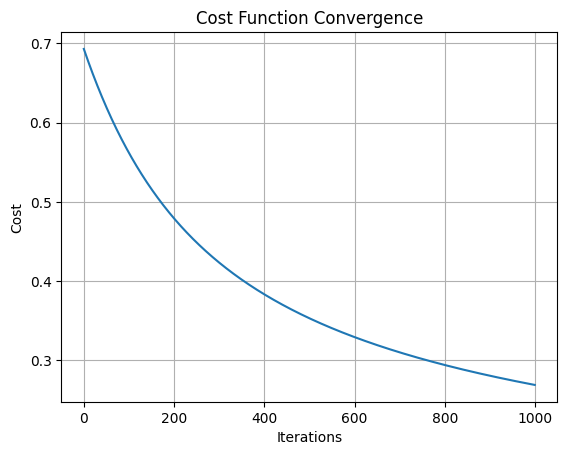

In [8]:
# Visualize
plt.plot(model.cost_history)
plt.title('Cost Function Convergence')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()